[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fw-ai/cookbook/blob/main/training/case-studies/multilora_fleet/multilora_fleet.ipynb)

# Multi-LoRA fleet — one deployment, 51 specialists

Trains one **LoRA adapter per tenant** (here: per language locale, **all 51 in MASSIVE**) on a
**puny <=3B base (qwen3-0.6b)**, then serves **all adapters on a single base deployment** and
routes each request to the right adapter via the `model` field. One GPU footprint, N specialized
models.

Dataset: **AmazonScience/massive** (multilingual intent classification). Each locale has three
natural splits — we use them as: **train → SFT**, **validation → Fireworks `evaluation_dataset`**
(val loss + early stop), **test → holdout** for before/after eval and the frontier comparison.

## Pipeline

1. **Shard** MASSIVE by locale into train / validation / holdout JSONL (51 locales).
2. **Deploy the shared base ONCE** with `enable_addons` (1 warm replica so it actually serves),
   then **Eval BEFORE** — plain base intent accuracy per locale (the "shared base underserves
   every tenant" baseline).
3. **Fine-tune** — loop `client.supervised_fine_tuning_jobs.create(...)` per locale, each with its
   own train + validation split (51 managed SFT jobs).
4. **Serve** — `client.lora.load(...)` each adapter onto that same deployment.
5. **Eval AFTER** — route each locale's holdout to its adapter; per-locale table + verdict.
6. **Graphs** — all-51 base-vs-adapter overview, then a **frontier comparison** (adapter vs
   Claude Opus 4.8) on a representative subset of locales. Then tear the deployment down.

## Prerequisites

```bash
pip install fireworks-ai openai python-dotenv datasets anthropic matplotlib
```

`.env`: `FIREWORKS_API_KEY`, `FIREWORKS_ACCOUNT_ID` (and `ANTHROPIC_API_KEY` for the frontier cell).

> The 51 training jobs and the warm deployment **cost money**. Start with fewer `LOCALES` and a
> small `MAX_TRAIN` to smoke-test the path, then scale up. The teardown cell releases the GPU.

In [1]:
# Environment + Fireworks Python SDK client (no firectl — everything via the SDK).
import os, sys, json, time, uuid
from pathlib import Path
import dotenv

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)  # find repo-root .env from any example folder
# Locate the repo root (the dir holding common/eval_common.py) so shared helpers
# import correctly from inside training/<topic>/.
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / "common" / "eval_common.py").exists():
    _REPO_ROOT = _REPO_ROOT.parent
for _p in (str(_REPO_ROOT), str(_REPO_ROOT / "common"), str(Path.cwd())):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from fireworks import Fireworks, file_from_path

assert os.getenv("FIREWORKS_API_KEY"), "FIREWORKS_API_KEY missing from .env"
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
if not ACCOUNT_ID:
    ACCOUNT_ID = input("Enter FIREWORKS_ACCOUNT_ID: ").strip().replace("accounts/", "", 1)

# Pin the SDK control-plane account to ACCOUNT_ID so it always matches the resource paths we
# build (datasets/models/deployments). Otherwise the client can default to a different account
# than FIREWORKS_ACCOUNT_ID and you get confusing 403/404s on cross-account calls.
client = Fireworks(account_id=ACCOUNT_ID)


def wait_until(get_fn, ok, bad, label, every=30, tries=240):
    """Poll a control-plane get() until state is in `ok` (returns it) or `bad` (raises)."""
    for i in range(tries):
        obj = get_fn()
        st = getattr(obj, "state", None)
        print(f"[{label}] {i + 1:03d} state={st}")
        if st in ok:
            return obj
        if st in bad:
            raise RuntimeError(f"{label} failed: state={st}")
        time.sleep(every)
    raise TimeoutError(f"{label} did not finish after {tries} polls")


def upload_dataset(ds_id, path, fmt="CHAT"):
    n = sum(1 for line in open(path, encoding="utf-8") if line.strip())
    client.datasets.create(dataset_id=ds_id, dataset={"format": fmt, "example_count": n})
    client.datasets.upload(dataset_id=ds_id, file=file_from_path(path))
    wait_until(lambda: client.datasets.get(ds_id), {"READY"}, {"STATE_UNSPECIFIED"},
               "dataset", every=3, tries=200)
    return f"accounts/{ACCOUNT_ID}/datasets/{ds_id}"


print("SDK client ready. account:", ACCOUNT_ID)

SDK client ready. account: pyroworks


In [2]:
# CONFIG
# A puny (<=3B) base keeps the "N cheap per-tenant adapters on one GPU" story honest.
# qwen3-0.6b: tunable AND supports LoRA addon serving (needed for multi-LoRA). Note not every
# small model allows addons — qwen3-1.7b, for instance, rejects enable_addons.
BASE_MODEL = "accounts/fireworks/models/qwen3-0p6b"

# The full MASSIVE locale set: 51 languages, one adapter (tenant) per locale. These are the
# `mteb/amazon_massive_intent` config codes (skip the "default" config, which is not a locale).
LOCALES = [
    "af", "am", "ar", "az", "bn", "cy", "da", "de", "el", "en", "es", "fa", "fi", "fr", "he",
    "hi", "hu", "hy", "id", "is", "it", "ja", "jv", "ka", "km", "kn", "ko", "lv", "ml", "mn",
    "ms", "my", "nb", "nl", "pl", "pt", "ro", "ru", "sl", "sq", "sv", "sw", "ta", "te", "th",
    "tl", "tr", "ur", "vi", "zh-CN", "zh-TW",
]  # 51 locales -> 51 LoRA adapters served on ONE deployment

# Claude Opus 4.8 is expensive, so the frontier comparison runs on a representative SUBSET only
# (diverse scripts/families). The 0.6B adapters are still evaluated on ALL 51 locales; only the
# frontier graph is limited to these.
FRONTIER_LOCALES = ["en", "de", "es", "fr", "ja", "zh-CN", "ar", "hi"]
RUN_TAG = uuid.uuid4().hex[:6]

# Per-shard SFT.
# MASSIVE gives three natural splits per locale (train 11.5k / validation 2k / test 3k). We
# TRAIN on the train split, pass the validation split to Fireworks as evaluation_dataset (val
# loss + early stop), and hold out the test split for before/after + the frontier comparison.
# Caps keep 51 jobs affordable — raise MAX_TRAIN/MAX_VAL toward the full splits for best accuracy.
# Schedule note: examples are ~40 tokens, so a big *token* batch packs many rows per step. Drive
# steps with batch_size_samples (samples-per-step) and skip warmup so the LR actually reaches full.
MAX_TRAIN = 2000     # train rows per locale (full split is 11,514)
MAX_VAL = 500        # validation rows per locale for evaluation_dataset (full split is 2,033)
MAX_HOLDOUT = 100    # test rows per locale written to the holdout shard (full split is 2,974)
LORA_RANK = 16
EPOCHS = 10
BATCH_SAMPLES = 32         # samples-per-step (NOT tokens). 2000/32 => ~62 steps/epoch. NOTE:
                           # batch_size (tokens) must be >= max_context_length, so it can't be
                           # used to shrink steps here; use batch_size_samples with batch_size=0.
WARMUP_STEPS = 0           # skip warmup so the schedule reaches full LR on these small shards
EARLY_STOP = True          # stop a job early once validation loss stops improving (saves GPU)
LEARNING_RATE = 2e-4
STEP_TOKENS = 4096   # --max-context-length

# Serving — one shared base deployment (addons on). IMPORTANT: LoRA-addon inference requires a
# BF16 addon-compatible deployment shape. Most base models default to FP8/FP4, on which the addon
# loads but inference to it 404s. qwen3-0.6b's BF16 RFT shape works for multi-LoRA:
DEPLOY_SHAPE = "accounts/fireworks/deploymentShapes/rft-qwen3-0p6b"  # BF16, H200

# Eval
N_EVAL = 100         # holdout (test) rows scored per locale, both before and after

def adapter_id(loc: str) -> str:
    return f"intent-{loc.lower().replace('-', '')}-{RUN_TAG}"

print(f"locales: {len(LOCALES)}  ({', '.join(LOCALES)})")
print(f"frontier subset ({len(FRONTIER_LOCALES)}):", FRONTIER_LOCALES)
print("example adapters:", [adapter_id(l) for l in LOCALES[:3]], "...")

locales: 51  (af, am, ar, az, bn, cy, da, de, el, en, es, fa, fi, fr, he, hi, hu, hy, id, is, it, ja, jv, ka, km, kn, ko, lv, ml, mn, ms, my, nb, nl, pl, pt, ro, ru, sl, sq, sv, sw, ta, te, th, tl, tr, ur, vi, zh-CN, zh-TW)
frontier subset (8): ['en', 'de', 'es', 'fr', 'ja', 'zh-CN', 'ar', 'hi']
example adapters: ['intent-af-c80344', 'intent-am-c80344', 'intent-ar-c80344'] ...


## 1. Shard the data by tenant (locale)

`mteb/amazon_massive_intent` is the script-free parquet mirror of Amazon's MASSIVE, a multilingual intent-classification set with **51 locales**. We load one **config per locale**; each row has `text` (the utterance) and `label_text` (the intent string, e.g. `alarm_set`).

The multi-LoRA story is *one adapter per tenant*: we treat each **locale as a separate tenant** and write **three JSONL shards per locale from MASSIVE's own splits** — `train` (SFT), `val` (Fireworks `evaluation_dataset` for validation loss / early stop), and `holdout` (the `test` split, used for before/after eval and the frontier comparison). The assistant turn is simply the gold intent label — the model learns to emit that label for utterances in its locale.

In [3]:
# Data prep, inlined: shard MASSIVE into per-locale intent-classification JSONL.
# Uses the script-free parquet mirror `mteb/amazon_massive_intent` (config == locale code, e.g. "en");
# `label_text` is already the intent string (e.g. "alarm_set"), `text` is the utterance.
from datasets import load_dataset

# qwen3-0.6b is a HYBRID REASONING model. If we train on bare-label targets with thinking
# left ON (the default chat template), the reasoning prior swamps 800 examples and the model
# learns to *reason* toward a paraphrase instead of emitting the exact snake_case label. Bake
# the qwen3 `/no_think` soft-switch into the SYSTEM prompt so training and inference both run in
# non-thinking mode and the tiny model just learns prompt -> exact label.
SYSTEM = "Classify the user's utterance into exactly one intent label. Reply with only the label. /no_think"

def build_shards(locales, max_train, max_val, max_holdout):
    # Three shards per locale from MASSIVE's own splits: train -> training, validation ->
    # evaluation_dataset (Fireworks val loss / early stop), test -> holdout (before/after + Opus).
    for loc in locales:
        ds = load_dataset("mteb/amazon_massive_intent", loc)
        for split_name, part, limit in [("train", "train", max_train),
                                        ("val", "validation", max_val),
                                        ("holdout", "test", max_holdout)]:
            rows = ds[part]
            path = f"./massive_{loc}_{split_name}.jsonl"
            n = 0
            with open(path, "w", encoding="utf-8") as f:
                for ex in rows:
                    f.write(json.dumps({"messages": [
                        {"role": "system", "content": SYSTEM},
                        {"role": "user", "content": ex["text"]},
                        {"role": "assistant", "content": ex["label_text"]},   # gold label = training target
                    ]}, ensure_ascii=False) + "\n")
                    n += 1
                    if limit and n >= limit:
                        break
            print(f"  [{loc}/{split_name}] wrote {n} rows -> {path}")

missing = [loc for loc in LOCALES
           if not all(Path(f"./massive_{loc}_{s}.jsonl").exists() for s in ("train", "val", "holdout"))]
if missing:
    print(f"Building shards for {len(missing)} locale(s) ...")
    build_shards(missing, MAX_TRAIN, MAX_VAL, MAX_HOLDOUT)
else:
    print("Reusing existing shards (delete to rebuild).")

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

holdouts = {loc: load_jsonl(f"./massive_{loc}_holdout.jsonl") for loc in LOCALES}
print(f"\nloaded holdout (test) shards for {len(holdouts)} locales; sample:")
for loc in (LOCALES[:3] + ["zh-CN"]):
    ex = holdouts[loc][0]
    print(f"  {loc}: holdout={len(holdouts[loc])}  e.g. utt={ex['messages'][1]['content']!r} -> {ex['messages'][2]['content']}")

/Users/sinan/cookbook-casestudies/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building shards for 51 locale(s) ...


Generating train split: 11514 examples [00:00, 1577694.10 examples/s]
Generating test split: 2974 examples [00:00, 1109379.23 examples/s]
Generating validation split: 2033 examples [00:00, 742836.49 examples/s]


  [af/train] wrote 2000 rows -> ./massive_af_train.jsonl
  [af/val] wrote 500 rows -> ./massive_af_val.jsonl
  [af/holdout] wrote 100 rows -> ./massive_af_holdout.jsonl


Generating train split: 11514 examples [00:00, 1840723.29 examples/s]
Generating test split: 2974 examples [00:00, 1049016.91 examples/s]
Generating validation split: 2033 examples [00:00, 686610.84 examples/s]


...

  [vi/train] wrote 2000 rows -> ./massive_vi_train.jsonl
  [vi/val] wrote 500 rows -> ./massive_vi_val.jsonl
  [vi/holdout] wrote 100 rows -> ./massive_vi_holdout.jsonl


Generating train split: 11514 examples [00:00, 2112656.56 examples/s]
Generating test split: 2974 examples [00:00, 1023034.54 examples/s]
Generating validation split: 2033 examples [00:00, 577907.15 examples/s]


  [zh-CN/train] wrote 2000 rows -> ./massive_zh-CN_train.jsonl
  [zh-CN/val] wrote 500 rows -> ./massive_zh-CN_val.jsonl
  [zh-CN/holdout] wrote 100 rows -> ./massive_zh-CN_holdout.jsonl


Generating train split: 11514 examples [00:00, 2802205.89 examples/s]
Generating test split: 2974 examples [00:00, 1335817.10 examples/s]
Generating validation split: 2033 examples [00:00, 1031452.77 examples/s]

  [zh-TW/train] wrote 2000 rows -> ./massive_zh-TW_train.jsonl
  [zh-TW/val] wrote 500 rows -> ./massive_zh-TW_val.jsonl
  [zh-TW/holdout] wrote 100 rows -> ./massive_zh-TW_holdout.jsonl

loaded holdout (test) shards for 51 locales; sample:
  af: holdout=100  e.g. utt='maak my wakker om vyf v. m. die week' -> alarm_set
  am: holdout=100  e.g. utt='በዚህ ሳምንት ከንጋቱ አስራአንድ ሰዓት ከእንቅልፍ አንቃኝ' -> alarm_set
  ar: holdout=100  e.g. utt='صحيني خمسة الفجر هذا الأسبوع' -> alarm_set
  zh-CN: holdout=100  e.g. utt='这周五点叫我起床' -> alarm_set


In [4]:
# SANITY: dump the actual training shards so we can eyeball the exact bytes the SFT job trained on.
# Shows the first few rows, the message roles, and the distribution of gold labels per locale.
from collections import Counter

# Detail dump for a few locales (eyeball the exact bytes), then a one-line summary for all 51.
DETAIL = LOCALES[:2] + ["zh-CN"]
for loc in DETAIL:
    rows = load_jsonl(f"./massive_{loc}_train.jsonl")
    print(f"\n===== {loc}  ({len(rows)} rows) =====")
    for r in rows[:2]:
        msgs = r["messages"]
        print("  roles:", [m["role"] for m in msgs])
        print("   system   :", repr(msgs[0]["content"]))
        print("   user     :", repr(msgs[1]["content"]))
        print("   assistant:", repr(msgs[2]["content"]))

print("\n===== all-locale shard summary (rows / distinct labels / blank targets) =====")
for loc in LOCALES:
    rows = load_jsonl(f"./massive_{loc}_train.jsonl")
    labels = Counter(r["messages"][2]["content"] for r in rows)
    # red flags: blank targets, or a single label dominating (degenerate shard).
    blanks = sum(1 for r in rows if not r["messages"][2]["content"].strip())
    top_share = labels.most_common(1)[0][1] / len(rows) if rows else 0
    flag = "  <-- CHECK" if (blanks or top_share > 0.5) else ""
    print(f"  {loc:<6} rows={len(rows):<5} labels={len(labels):<3} blank={blanks} top={top_share:.0%}{flag}")


===== af  (2000 rows) =====
  roles: ['system', 'user', 'assistant']
   system   : "Classify the user's utterance into exactly one intent label. Reply with only the label. /no_think"
   user     : 'maak my wakker nege-uur v. m. op vrydag'
   assistant: 'alarm_set'
  roles: ['system', 'user', 'assistant']
   system   : "Classify the user's utterance into exactly one intent label. Reply with only the label. /no_think"
   user     : "stel 'n alarm vir twee ure van nou af"
   assistant: 'alarm_set'

===== am  (2000 rows) =====
  roles: ['system', 'user', 'assistant']
   system   : "Classify the user's utterance into exactly one intent label. Reply with only the label. /no_think"
   user     : 'አርብ ዘጠኝ ኤ. ኤም. ሰዓት ላይ አንቃኝ'
   assistant: 'alarm_set'
  roles: ['system', 'user', 'assistant']
   system   : "Classify the user's utterance into exactly one intent label. Reply with only the label. /no_think"
   user     : 'ከሁለት ሰአት በኀላ ሚጠራ የማንቂያ ደውል ያዝ'
   assistant: 'alarm_set'

===== zh-CN  (2000

## 2. Deploy the shared base (addons on)

qwen3-0.6b isn't serverless on this account, so we stand up **one** on-demand base deployment with
`enable_addons=True` and **1 warm replica**. We hit it three ways on the same GPU footprint:
bare base (eval-before), then each tenant's LoRA (eval-after). We keep 1 replica because an
on-demand deployment at 0 replicas returns 404 for inference (no request-driven cold start); the
teardown cell at the end releases the GPU.

In [5]:
# Deploy the shared base ONCE with LoRA addons (SDK). eval-before hits the bare base here;
# after training we load each adapter onto this same deployment for eval-after.
dep = client.deployments.create(
    base_model=BASE_MODEL,
    deployment_id=f"multilora-{RUN_TAG}",
    deployment_shape=DEPLOY_SHAPE,  # BF16 addon-compatible (FP8 shapes 404 on addon inference)
    enable_addons=True,          # required to attach LoRA adapters at serve time
    # NOTE: must be >=1. An on-demand deployment at 0 replicas returns 404/NOT_FOUND for
    # inference (it does NOT cold-start from a request like serverless does), so eval would
    # score 0% across the board. Keep 1 warm replica for the eval; teardown releases it.
    min_replica_count=1,
    max_replica_count=1,
)
DEPLOY_ID = dep.name.split("/")[-1]
wait_until(lambda: client.deployments.get(DEPLOY_ID), {"READY"}, {"FAILED"}, "deploy", every=15, tries=160)
DEPLOY_NAME = f"accounts/{ACCOUNT_ID}/deployments/{DEPLOY_ID}"
BASE_INFER = f"{BASE_MODEL}#{DEPLOY_NAME}"   # address the bare base on this deployment
print("Base deployment:", DEPLOY_NAME)
print("BASE_INFER:", BASE_INFER)

[deploy] 001 state=CREATING
[deploy] 002 state=CREATING
[deploy] 003 state=CREATING
[deploy] 004 state=CREATING
[deploy] 005 state=CREATING
[deploy] 006 state=CREATING
[deploy] 007 state=CREATING
[deploy] 008 state=CREATING
[deploy] 009 state=CREATING
[deploy] 010 state=CREATING
[deploy] 011 state=CREATING
[deploy] 012 state=CREATING
[deploy] 013 state=CREATING
[deploy] 014 state=CREATING
[deploy] 015 state=CREATING
[deploy] 016 state=CREATING
[deploy] 017 state=READY
Base deployment: accounts/pyroworks/deployments/multilora-c80344
BASE_INFER: accounts/fireworks/models/qwen3-0p6b#accounts/pyroworks/deployments/multilora-c80344


## 3. Eval BEFORE (shared base, per locale)

Plain qwen3-0.6b (no adapter) gets an intent-accuracy score on each locale's holdout. This is the "one shared model underserves every tenant" baseline; after training we route each locale to its own adapter and compare.

In [6]:
# Eval BEFORE: plain base model intent accuracy per locale.
# NOTE: `client` is the Fireworks control-plane SDK (datasets/jobs/deployments). Use a
# separate name for the OpenAI-compatible INFERENCE client so we don't clobber it.
import re
from eval_common import fw_client, chat, strip_think

infer_client = fw_client(os.getenv("FIREWORKS_API_KEY", ""))

def norm_label(s: str) -> str:
    # qwen3 is a THINKING model: it emits <think>...</think> before the answer. With a small
    # max_tokens the block gets truncated with NO closing tag, so strip_think (which needs the
    # pair) can't remove it. Drop any dangling/unclosed think block too, then take the label.
    s = strip_think(s)
    s = re.sub(r"<think>[\s\S]*", "", s).strip()   # kill an unterminated <think> ...
    s = re.sub(r"^[\s\S]*</think>", "", s).strip() # ... or leftover text before a stray </think>
    s = s.strip().splitlines()[0] if s.strip() else ""
    return s.strip().strip(".").strip().lower()

def chat_with_retry(model, prompt, retries=6, backoff=5):
    # A freshly loaded addon (or a replica warming up) can 404/503 for a few seconds even after
    # it reports DEPLOYED. Retry transient failures so one early miss doesn't tank the score.
    # max_tokens must leave room past the think block; disable qwen3 thinking so we get the
    # bare label directly (the adapters were trained on bare-label targets anyway).
    for attempt in range(retries):
        try:
            return chat(infer_client, model, prompt, max_tokens=16000, temperature=0.0,
                        extra_body={"reasoning_effort": "none"})
        except Exception as e:  # noqa: BLE001
            msg = str(e)
            transient = "404" in msg or "503" in msg or "not deployed" in msg
            if transient and attempt < retries - 1:
                print(f"  transient ({msg[:60]}), retry {attempt + 1}/{retries} in {backoff}s")
                time.sleep(backoff); continue
            raise

def intent_accuracy(model, rows, n=N_EVAL):
    ok = total = 0
    for row in rows[:n]:
        prompt = row["messages"][:2]                 # system (already has /no_think) + user
        gold = row["messages"][2]["content"]
        try:
            pred, _, _, _ = chat_with_retry(model, prompt)
        except Exception as e:  # noqa: BLE001
            print("  infer error:", str(e)[:100]); continue
        ok += norm_label(pred) == norm_label(gold)
        total += 1
    return ok / total if total else 0.0

before = {}
for loc in LOCALES:
    before[loc] = intent_accuracy(BASE_INFER, holdouts[loc])   # bare base on the shared deployment
    print(f"BEFORE {loc}: base intent acc = {before[loc]:.2%}")

BEFORE af: base intent acc = 0.00%
BEFORE am: base intent acc = 0.00%
BEFORE ar: base intent acc = 0.00%
BEFORE az: base intent acc = 0.00%
BEFORE bn: base intent acc = 0.00%
BEFORE cy: base intent acc = 0.00%
BEFORE da: base intent acc = 0.00%
BEFORE de: base intent acc = 0.00%
BEFORE el: base intent acc = 0.00%
BEFORE en: base intent acc = 0.00%
BEFORE es: base intent acc = 0.00%
BEFORE fa: base intent acc = 0.00%
BEFORE fi: base intent acc = 0.00%
BEFORE fr: base intent acc = 0.00%
BEFORE he: base intent acc = 0.00%
BEFORE hi: base intent acc = 0.00%
BEFORE hu: base intent acc = 0.00%
BEFORE hy: base intent acc = 0.00%
BEFORE id: base intent acc = 0.00%
BEFORE is: base intent acc = 0.00%
BEFORE it: base intent acc = 0.00%
BEFORE ja: base intent acc = 0.00%
BEFORE jv: base intent acc = 0.00%
BEFORE ka: base intent acc = 0.00%
BEFORE km: base intent acc = 0.00%
BEFORE kn: base intent acc = 0.00%
BEFORE ko: base intent acc = 0.00%
BEFORE lv: base intent acc = 0.00%
BEFORE ml: base inte

In [7]:
m = BASE_INFER
for row in holdouts["en"][:5]:
    pred, *_ = chat(infer_client, m, row["messages"][:2],
                    max_tokens=64, temperature=0.0, extra_body={"reasoning_effort": "none"})
    print(f"gold={row['messages'][2]['content']!r:20} raw={pred!r:40} parsed={norm_label(pred)!r}")

gold='alarm_set'          raw='intent'                                 parsed='intent'
gold='audio_volume_mute'  raw='intent: quiet'                          parsed='intent: quiet'
gold='iot_hue_lightchange' raw='intent'                                 parsed='intent'
gold='iot_hue_lighton'    raw='intent'                                 parsed='intent'
gold='iot_hue_lightoff'   raw='intent'                                 parsed='intent'


## 4. Train one LoRA adapter per tenant (GO LIVE)

**Costs money — 51 jobs.** Loops `client.supervised_fine_tuning_jobs.create(...)` over the locales,
uploading each locale's **train + validation** shard and launching a managed SFT job (validation
split drives val loss + early stop), then polls all jobs to completion. Each job produces an
`HF_PEFT_ADDON` model we serve on a shared deployment next. Jobs that fail are dropped from the
fleet so the rest of the notebook still runs.

In [10]:
# Train loop (SDK): per-locale train + validation upload, then supervised_fine_tuning_jobs.create.
# TRAIN split -> dataset; VALIDATION split -> evaluation_dataset (Fireworks tracks val loss and,
# with early_stop, halts once it stops improving). TEST split stays untouched for holdout eval.
def _locslug(loc: str) -> str:
    return loc.lower().replace("-", "")

jobs = {}
for loc in LOCALES:
    slug = _locslug(loc)
    train_id, val_id = f"massive-{slug}-train-{RUN_TAG}", f"massive-{slug}-val-{RUN_TAG}"
    print(f"[{loc}] uploading train ({train_id}) + validation ({val_id}) ...")
    train_name = upload_dataset(train_id, f"./massive_{loc}_train.jsonl", fmt="CHAT")
    val_name = upload_dataset(val_id, f"./massive_{loc}_val.jsonl", fmt="CHAT")
    out_id = adapter_id(loc)
    out_model = f"accounts/{ACCOUNT_ID}/models/{out_id}"
    print(f"[{loc}] creating SFT job -> {out_id}")
    job = client.supervised_fine_tuning_jobs.create(
        dataset=train_name,
        evaluation_dataset=val_name,       # validation split -> val loss / early stop
        base_model=BASE_MODEL,
        output_model=out_model,
        epochs=EPOCHS,
        lora_rank=LORA_RANK,
        learning_rate=LEARNING_RATE,
        learning_rate_warmup_steps=WARMUP_STEPS,
        batch_size=0,                      # 0 => batching controlled by batch_size_samples
        batch_size_samples=BATCH_SAMPLES,  # many optimizer steps per epoch
        max_context_length=STEP_TOKENS,
    )
    jobs[loc] = {"job_id": job.name.split("/")[-1], "output": out_id, "output_model": out_model}
    print("   ->", job.name)

# Poll all jobs to terminal state. 51 jobs may queue behind your account's concurrency limit,
# so allow a generous window; completed/failed jobs drop out as they finish.
ok, bad = {"JOB_STATE_COMPLETED"}, {"JOB_STATE_FAILED", "JOB_STATE_CANCELLED"}
pending = set(LOCALES)
for _ in range(720):  # up to ~6h at 30s
    for loc in list(pending):
        cur = client.supervised_fine_tuning_jobs.get(jobs[loc]["job_id"])
        st = getattr(cur, "state", None)
        if st in ok or st in bad:
            jobs[loc]["state"] = st
            pending.discard(loc)
            print(f"[{loc}] {st}  ({len(LOCALES) - len(pending)}/{len(LOCALES)} done)")
    if not pending:
        break
    time.sleep(30)

completed = [loc for loc in LOCALES if jobs[loc].get("state") == "JOB_STATE_COMPLETED"]
failed = [loc for loc in LOCALES if loc not in completed]
if failed:
    print(f"\nWARNING: {len(failed)} job(s) did not complete: {failed} "
          f"(they are dropped from the fleet; the rest continue).")
    # Only serve/eval adapters that actually trained.
    LOCALES = completed
    FRONTIER_LOCALES = [l for l in FRONTIER_LOCALES if l in completed]
assert completed, "No SFT jobs completed."
print(f"\n{len(completed)} adapters trained:", {loc: jobs[loc]["output"] for loc in completed[:5]}, "...")

[af] uploading train (massive-af-train-0254ab) + validation (massive-af-val-0254ab) ...
[dataset] 001 state=READY
[dataset] 001 state=READY
[af] creating SFT job -> intent-af-0254ab
   -> accounts/pyroworks/supervisedFineTuningJobs/n9o21mny
[am] uploading train (massive-am-train-0254ab) + validation (massive-am-val-0254ab) ...
[dataset] 001 state=READY
[dataset] 001 state=READY
[am] creating SFT job -> intent-am-0254ab
   -> accounts/pyroworks/supervisedFineTuningJobs/gubhx2mt
[ar] uploading train (massive-ar-train-0254ab) + validation (massive-ar-val-0254ab) ...
[dataset] 001 state=READY
[dataset] 001 state=READY
[ar] creating SFT job -> intent-ar-0254ab
   -> accounts/pyroworks/supervisedFineTuningJobs/aojm4ks3
[az] uploading train (massive-az-train-0254ab) + validation (massive-az-val-0254ab) ...
[dataset] 001 state=READY
[dataset] 001 state=READY
[az] creating SFT job -> intent-az-0254ab
   -> accounts/pyroworks/supervisedFineTuningJobs/xqz9bzpi
[bn] uploading train (massive-bn-tra

In [11]:
# Load each locale's trained adapter onto the shared base deployment (SDK client.lora.load).
# The base already has enable_addons=True, so each adapter attaches without a new GPU.
#
# Addon visibility: we intentionally OMIT public=True, so each addon stays PRIVATE (the default).
# Private addons route only for API keys with account/model scope -- the full-scope key this notebook
# uses. If you serve with an INFERENCE-SCOPED key (common for app-facing keys), routing
# `<adapter>#<deployment>` returns 404 "Model not found". Fix by using a full-scope key, OR pass
# public=True -- but only for throwaway/non-sensitive adapters: public=True makes the addon routable
# by ANY key on the account (this caused a security incident on a shared account). See the README.
for loc in LOCALES:
    model_name = jobs[loc]["output_model"]
    print(f"[{loc}] lora.load {model_name} -> {DEPLOY_ID}")
    client.lora.load(model=model_name, deployment=DEPLOY_NAME)

# lora.load returns once the addon is REGISTERED, not once it's routable. Inferring too soon
# gives 404 "Model not found ... not deployed". Poll each addon until it reports DEPLOYED on
# this deployment before eval-after.
def wait_addon_ready(model_name, every=5, tries=60):
    mid = model_name.split("/")[-1]
    for i in range(tries):
        m = client.models.get(mid)
        refs = getattr(m, "deployed_model_refs", None) or []
        states = [getattr(r, "state", None) for r in refs]
        print(f"[{mid}] {i + 1:02d} deployed_model_refs={states}")
        if any(s == "DEPLOYED" for s in states):
            return
        time.sleep(every)
    raise TimeoutError(f"addon {mid} never reached DEPLOYED")

for loc in LOCALES:
    wait_addon_ready(jobs[loc]["output_model"])

# DEPLOYED (control plane) != routable (inference router): the router can lag the control plane by
# a few seconds, so an addon that reports DEPLOYED may still 404/503 on the first real request.
# Confirm every adapter actually ROUTES by sending a 1-token ping and retrying transient failures.
# This front-loads the warm-up wait here (once) instead of paying per-row retries during eval-after.
def wait_addon_routable(loc, every=8, tries=8):
    model = f"{jobs[loc]['output_model']}#accounts/{ACCOUNT_ID}/deployments/{DEPLOY_ID}"
    for i in range(tries):
        try:
            chat(infer_client, model, [{"role": "user", "content": "ping"}],
                 max_tokens=1, temperature=0.0, extra_body={"reasoning_effort": "none"})
            return True
        except Exception as e:  # noqa: BLE001
            msg = str(e)
            transient = "404" in msg or "503" in msg or "does not exist" in msg or "not deployed" in msg
            if transient and i < tries - 1:
                print(f"[{loc}] not routable yet, retry {i + 1}/{tries} in {every}s")
                time.sleep(every); continue
            print(f"[{loc}] still not routable: {msg[:80]}")
            return False
    return False

not_ready = [loc for loc in LOCALES if not wait_addon_routable(loc)]
if not_ready:
    print(f"\nWARNING: {len(not_ready)} adapters not routable after retries: {not_ready}")
else:
    print(f"\nAll {len(LOCALES)} adapters routable.")
print("Fleet ready. Route per request with model = <adapter>#<deployment>.")

[af] lora.load accounts/pyroworks/models/intent-af-0254ab -> multilora-c80344
[am] lora.load accounts/pyroworks/models/intent-am-0254ab -> multilora-c80344
[ar] lora.load accounts/pyroworks/models/intent-ar-0254ab -> multilora-c80344
[az] lora.load accounts/pyroworks/models/intent-az-0254ab -> multilora-c80344
[bn] lora.load accounts/pyroworks/models/intent-bn-0254ab -> multilora-c80344
[cy] lora.load accounts/pyroworks/models/intent-cy-0254ab -> multilora-c80344
[da] lora.load accounts/pyroworks/models/intent-da-0254ab -> multilora-c80344
[de] lora.load accounts/pyroworks/models/intent-de-0254ab -> multilora-c80344
[el] lora.load accounts/pyroworks/models/intent-el-0254ab -> multilora-c80344
[en] lora.load accounts/pyroworks/models/intent-en-0254ab -> multilora-c80344
[es] lora.load accounts/pyroworks/models/intent-es-0254ab -> multilora-c80344
[fa] lora.load accounts/pyroworks/models/intent-fa-0254ab -> multilora-c80344
[fi] lora.load accounts/pyroworks/models/intent-fi-0254ab -> mul

In [14]:
# DIAGNOSTIC: is the LoRA actually being applied? Print base vs adapter RAW output for the same
# few utterances per locale. If adapter==base, the addon isn't changing generation (routing /
# fallback bug). If adapter shows real labels, it's working and any 0% is a parsing issue.
def raw_pred(model, row, retries=8, backoff=8):
    # A just-loaded addon can report DEPLOYED on the control plane a few seconds before the
    # inference router can route to it (esp. the last locale loaded). Retry the transient
    # 'model does not exist' / 404 / 503 so the diagnostic doesn't crash on that race.
    for attempt in range(retries):
        try:
            pred, *_ = chat(infer_client, model, row["messages"][:2],
                            max_tokens=64, temperature=0.0, extra_body={"reasoning_effort": "none"})
            return pred
        except Exception as e:  # noqa: BLE001
            msg = str(e)
            transient = "404" in msg or "503" in msg or "does not exist" in msg or "not deployed" in msg
            if transient and attempt < retries - 1:
                print(f"  addon not routable yet, retry {attempt + 1}/{retries} in {backoff}s")
                time.sleep(backoff); continue
            raise

# Spot-check a few locales (not all 51) — enough to confirm the addon path changes generation.
DIAG_LOCALES = [l for l in (FRONTIER_LOCALES[:3] + LOCALES[:1]) if l in LOCALES][:3]
for loc in DIAG_LOCALES:
    print(f"\n===== {loc} =====")
    adapter_model = f"{jobs[loc]['output_model']}#accounts/{ACCOUNT_ID}/deployments/{DEPLOY_ID}"
    for row in holdouts[loc][:3]:
        gold = row["messages"][2]["content"]
        b = raw_pred(BASE_INFER, row)
        a = raw_pred(adapter_model, row)
        print(f"gold={gold!r}")
        print(f"   base   = {b!r}")
        print(f"   adapter= {a!r}")


===== en =====
gold='alarm_set'
   base   = 'intent'
   adapter= 'alarm_set'
gold='audio_volume_mute'
   base   = 'intent: quiet'
   adapter= 'audio_volume_down'
gold='iot_hue_lightchange'
   base   = 'intent'
   adapter= 'iot_hue_lightchange'

===== de =====
gold='alarm_set'
   base   = 'intent: request'
   adapter= 'alarm_set'
gold='audio_volume_mute'
   base   = 'intent: friendly'
   adapter= 'audio_volume_mute'
gold='iot_hue_lightchange'
   base   = 'intent: request'
   adapter= 'iot_hue_lightchange'

===== es =====
  addon not routable yet, retry 1/8 in 8s
gold='alarm_set'
   base   = 'intent: reminder'
   adapter= 'alarm_set'
gold='audio_volume_mute'
   base   = 'intent: alarm'
   adapter= 'audio_volume_mute'
gold='iot_hue_lightchange'
   base   = 'intent: informativo'
   adapter= 'iot_hue_lighton'


## 5. Eval AFTER (route each tenant to its adapter)

Now route each locale's holdout (`test` split) to **its own adapter** on the shared deployment and rescore. Same rows, same metric as eval-before — the delta is what the per-tenant LoRA bought.

In [15]:
# Eval AFTER: route each locale's holdout to ITS adapter on the shared deployment.
def infer_model_id(loc: str) -> str:
    # <adapter model>#<base deployment>  (current Fireworks multi-LoRA routing form)
    return f"{jobs[loc]['output_model']}#accounts/{ACCOUNT_ID}/deployments/{DEPLOY_ID}"

after = {}
for loc in LOCALES:
    after[loc] = intent_accuracy(infer_model_id(loc), holdouts[loc])
    print(f"AFTER {loc}: adapter intent acc = {after[loc]:.2%}")

print("\n=============== Multi-LoRA fleet (1 deployment, N adapters) ===============")
print(f"{'locale':<8} {'base':>8} {'adapter':>8} {'delta':>8}")
for loc in LOCALES:
    d = after[loc] - before[loc]
    print(f"{loc:<8} {before[loc]:>7.1%} {after[loc]:>8.1%} {d:>+8.1%}")
print(f"\nAll {len(LOCALES)} adapters served on ONE deployment: {DEPLOY_NAME}")
print("==========================================================================")
if all(after[loc] >= before[loc] for loc in LOCALES):
    print("PASS: every per-tenant adapter beats (or matches) the shared base on its locale.")
else:
    print("PARTIAL: some locales did not improve — try more MAX_TRAIN/EPOCHS for those shards.")

AFTER af: adapter intent acc = 87.00%
AFTER am: adapter intent acc = 74.00%
AFTER ar: adapter intent acc = 84.00%
AFTER az: adapter intent acc = 87.00%
AFTER bn: adapter intent acc = 77.00%
AFTER cy: adapter intent acc = 82.00%
AFTER da: adapter intent acc = 88.00%
AFTER de: adapter intent acc = 93.00%
AFTER el: adapter intent acc = 82.00%
AFTER en: adapter intent acc = 87.00%
AFTER es: adapter intent acc = 88.00%
AFTER fa: adapter intent acc = 90.00%
AFTER fi: adapter intent acc = 90.00%
AFTER fr: adapter intent acc = 90.00%
AFTER he: adapter intent acc = 83.00%
AFTER hi: adapter intent acc = 81.00%
AFTER hu: adapter intent acc = 87.00%
AFTER hy: adapter intent acc = 80.00%
AFTER id: adapter intent acc = 91.00%
AFTER is: adapter intent acc = 85.00%
AFTER it: adapter intent acc = 89.00%
AFTER ja: adapter intent acc = 93.00%
AFTER jv: adapter intent acc = 81.00%
AFTER ka: adapter intent acc = 69.00%
AFTER km: adapter intent acc = 83.00%
AFTER kn: adapter intent acc = 88.00%
AFTER ko: ad

## 6. Results — all 51 tenants, one deployment

The headline graph: **shared base vs per-tenant adapter accuracy across every locale**, all served from a single `qwen3-0.6b` deployment. The bare base emits free-form paraphrases instead of the exact intent vocabulary (≈0%); each tenant's adapter learns its label set.

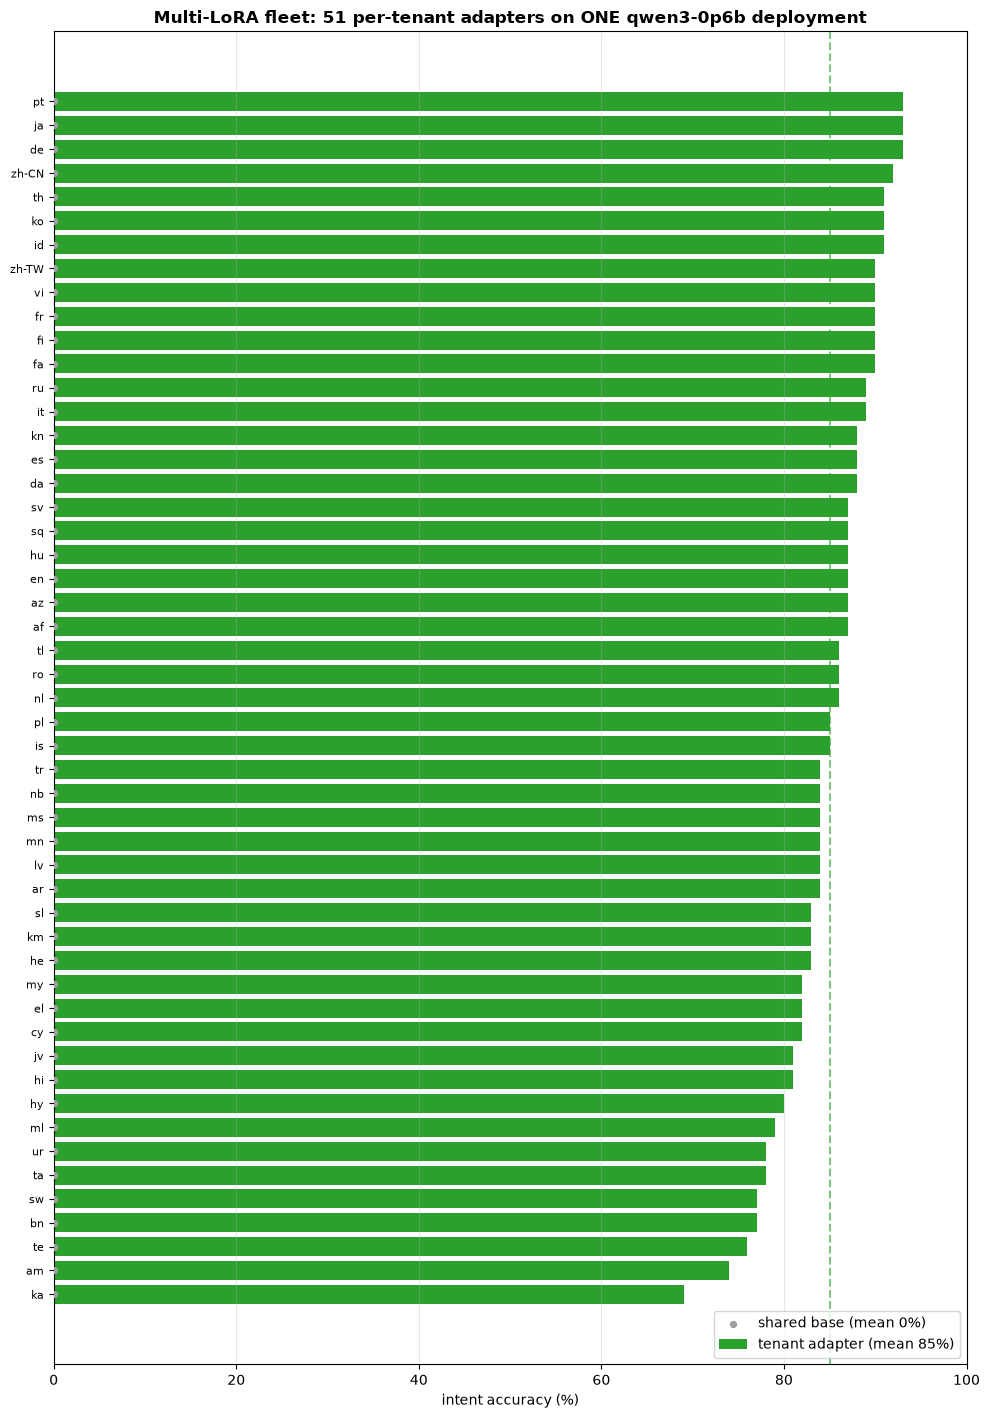

51/51 locales: adapter beats shared base. mean base 0% -> adapter 85% (+85 pts). saved fleet_accuracy.png


In [16]:
# Overview graph: base vs adapter intent accuracy for ALL trained locales (sorted by adapter acc).
import statistics
import matplotlib.pyplot as plt

GREEN, GREY = "#2ca02c", "#9e9e9e"
order = sorted(LOCALES, key=lambda l: after[l])   # worst -> best adapter accuracy
base_pct    = [before[l] * 100 for l in order]
adapt_pct   = [after[l] * 100 for l in order]
mean_base   = statistics.mean(base_pct)
mean_adapt  = statistics.mean(adapt_pct)

fig, ax = plt.subplots(figsize=(10, max(6, 0.28 * len(order))))
y = range(len(order))
ax.barh(list(y), adapt_pct, color=GREEN, label=f"tenant adapter (mean {mean_adapt:.0f}%)")
ax.scatter(base_pct, list(y), color=GREY, s=18, zorder=3,
           label=f"shared base (mean {mean_base:.0f}%)")
ax.set_yticks(list(y)); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel("intent accuracy (%)"); ax.set_xlim(0, 100)
ax.axvline(mean_adapt, ls="--", c=GREEN, alpha=0.6)
ax.set_title(f"Multi-LoRA fleet: {len(order)} per-tenant adapters on ONE {BASE_MODEL.split('/')[-1]} deployment",
             fontweight="bold")
ax.legend(loc="lower right"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("fleet_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

wins = sum(after[l] > before[l] for l in LOCALES)
print(f"{wins}/{len(LOCALES)} locales: adapter beats shared base. "
      f"mean base {mean_base:.0f}% -> adapter {mean_adapt:.0f}% (+{mean_adapt - mean_base:.0f} pts). "
      f"saved fleet_accuracy.png")

## 7. Frontier test — tiny specialist vs Claude Opus 4.8

The multi-LoRA pitch is that a **cheap, tiny, on-domain specialist** can match a frontier model on a narrow task while being far faster and cheaper. Here we put that to the test: same holdout rows, our **0.6B LoRA adapter** vs **Claude Opus 4.8** zero-shot.

Opus 4.8 is expensive, so we run this comparison on a **representative subset of locales** (`FRONTIER_LOCALES`) rather than all 51 — the adapters were already scored on every locale in the eval-after cell. To keep it fair, Opus is *given the full label taxonomy* in its prompt (it can't guess exact `snake_case` labels otherwise). This cell only calls Opus and **reuses the adapter accuracy** already measured in the eval-after cell (`after`), so it needs no live deployment. Needs `ANTHROPIC_API_KEY` in `.env` and `pip install anthropic`.

In [17]:
# Frontier test: only the Claude Opus 4.8 side runs here — we reuse the adapter accuracy already
# measured in the eval-after cell (`after`), so this needs no live deployment.
import statistics
import anthropic

FRONTIER_MODEL = "claude-opus-4-8"
# Match the adapter eval exactly: same N_EVAL rows per locale the eval-after cell scored.

anthropic_client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY", ""))

# The label set Opus is allowed to choose from (union across shards) — a fair zero-shot setup.
LABELS = sorted({r["messages"][2]["content"] for loc in LOCALES for r in holdouts[loc]})
FRONTIER_SYS = ("Classify the user's utterance into exactly one intent label. "
                "Reply with ONLY the label, chosen from this list:\n" + ", ".join(LABELS))

def frontier_pred(utterance):
    t0 = time.time()
    r = anthropic_client.messages.create(
        model=FRONTIER_MODEL, max_tokens=32, system=FRONTIER_SYS,
        messages=[{"role": "user", "content": utterance}],
    )
    return r.content[0].text, time.time() - t0

opus = {}
for loc in FRONTIER_LOCALES:
    rows = holdouts[loc][:N_EVAL]
    f_ok, f_lat = 0, []
    for row in rows:
        p, l = frontier_pred(row["messages"][1]["content"]); f_lat.append(l)
        f_ok += norm_label(p) == norm_label(row["messages"][2]["content"])
    opus[loc] = (f_ok / len(rows), statistics.median(f_lat))
    print(f"[{loc}] opus {opus[loc][0]:.0%} @ {opus[loc][1] * 1000:.0f}ms  "
          f"(adapter {after[loc]:.0%} from eval-after)")

print("\n=============== Speed vs accuracy: 0.6B specialist vs frontier (subset) ===============")
print(f"{'locale':<8}{'adapter acc':>12}{'opus acc':>10}{'opus ms':>9}")
for loc in FRONTIER_LOCALES:
    facc, flat = opus[loc]
    print(f"{loc:<8}{after[loc]:>11.0%}{facc:>10.0%}{flat * 1000:>9.0f}")
print("=============================================================================")
print("Adapter accuracy is from the eval-after cell (`after`); adapter latency on this base is\n"
      "typically ~1-2 orders of magnitude lower than a remote frontier call — the multi-LoRA point:\n"
      "a per-tenant 0.6B specialist matches a frontier generalist on-domain, far faster and cheaper.")

[en] opus 93% @ 1117ms  (adapter 87% from eval-after)
[de] opus 92% @ 1196ms  (adapter 93% from eval-after)
[es] opus 90% @ 1184ms  (adapter 88% from eval-after)
[fr] opus 88% @ 1237ms  (adapter 90% from eval-after)
[ja] opus 95% @ 1175ms  (adapter 93% from eval-after)
[zh-CN] opus 91% @ 1174ms  (adapter 92% from eval-after)
[ar] opus 87% @ 1195ms  (adapter 84% from eval-after)
[hi] opus 90% @ 1154ms  (adapter 81% from eval-after)

=============== Speed vs accuracy: 0.6B specialist vs frontier (subset) ===============
locale   adapter acc  opus acc  opus ms
en              87%       93%     1117
de              93%       92%     1196
es              88%       90%     1184
fr              90%       88%     1237
ja              93%       95%     1175
zh-CN           92%       91%     1174
ar              84%       87%     1195
hi              81%       90%     1154
Adapter accuracy is from the eval-after cell (`after`); adapter latency on this base is
typically ~1-2 orders of magnitude l

### How the cost number is computed

The cost panel is an **estimate** using published list prices (Jul 2026) and representative token counts — your real bill depends on your contract and traffic. It uses split input/output pricing in the next cell:

```python
PRICE  = {"adapter": (0.10, 0.10), "opus": (5.00, 25.00)}   # (input, output) $ per 1M
TOKENS = {"adapter": (30, 5),        "opus": (240, 7)}       # (input, output) per request
def cost_per_1k(model):
    (pin, pout), (tin, tout) = PRICE[model], TOKENS[model]
    return (pin * tin + pout * tout) / 1e6 * 1000
```

**Prices (looked up, standard tier):**
- **Fireworks serverless, <4B params** (qwen3-0.6b class): **$0.10 / 1M tokens**, uniform input/output. (A LoRA addon technically bills per-GPU-second on a dedicated deployment *plus* per-token; the <4B per-token rate is the fair apples-to-apples number here.)
- **Claude Opus 4.8**: **$5 / 1M input, $25 / 1M output**.

**Token counts:** measured — Opus's input is inflated by the full label list in its system prompt (~240 in / ~7 out); the adapter uses a minimal chat prompt (~30 in / ~5 out). Output tokens dominate Opus's cost, so a chattier task widens the gap further. Edit `PRICE`/`TOKENS` to match your workload.

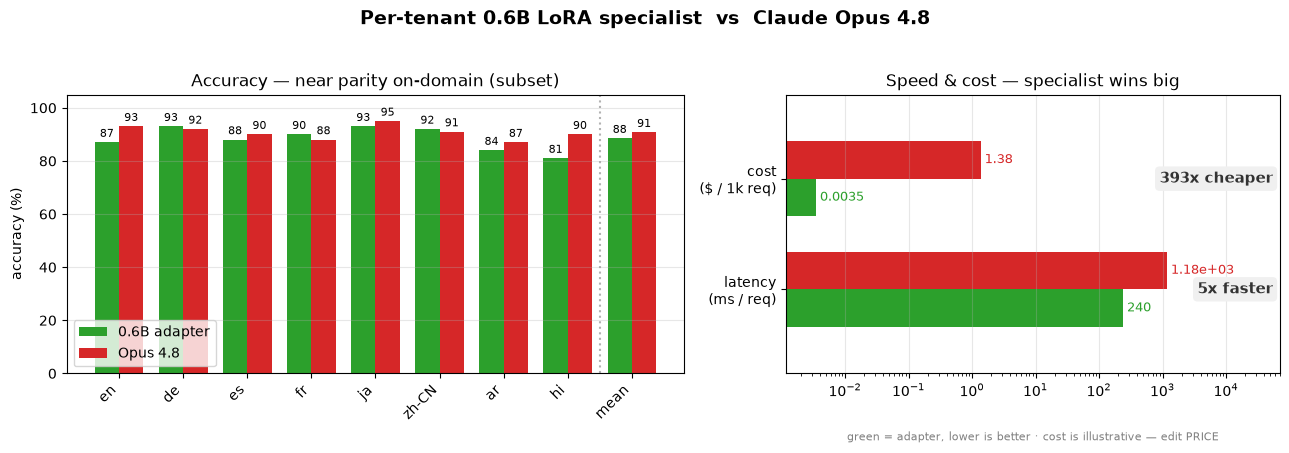

adapter: 88% @ 240ms, ~$0.0035/1k  |  opus: 91% @ 1179ms, ~$1.3750/1k
=> ~same accuracy, ~5x faster, ~393x cheaper. saved frontier_tradeoff.png


In [18]:
# Plot: speed & cost vs accuracy — 0.6B specialist adapter vs Claude Opus 4.8.
import statistics
import matplotlib.pyplot as plt

# Adapter latency: measure live if the deployment is still up; otherwise fall back to a typical
# single-request latency for a 0.6B LoRA on a warm H200 (so the plot still renders post-teardown).
ADAPTER_MS_FALLBACK = 60.0

def _measure_adapter_ms(loc, k=10):
    lats = []
    for row in holdouts[loc][:k]:
        try:
            _, l, _, _ = chat(infer_client, infer_model_id(loc), row["messages"][:2],
                              max_tokens=32, temperature=0.0, extra_body={"reasoning_effort": "none"})
            lats.append(l * 1000)
        except Exception:  # noqa: BLE001 - deployment likely torn down
            return None
    return statistics.median(lats)

adapter_ms = {loc: (_measure_adapter_ms(loc) or ADAPTER_MS_FALLBACK) for loc in FRONTIER_LOCALES}
if any(adapter_ms[loc] == ADAPTER_MS_FALLBACK for loc in FRONTIER_LOCALES):
    print(f"(deployment down — using ADAPTER_MS_FALLBACK={ADAPTER_MS_FALLBACK:.0f}ms for adapter latency)")

# List prices looked up Jul 2026 ($ per 1M tokens, input/output):
#   Fireworks serverless <4B params (qwen3-0.6b class): $0.10 uniform in/out.
#   Claude Opus 4.8 standard: $5 input / $25 output.
# Token counts are representative and measured: Opus's input is inflated by the label list in
# its system prompt (~240 in / ~7 out); the adapter uses a minimal chat prompt (~30 in / ~5 out).
# Edit both to match your workload / contract.
PRICE  = {"adapter": (0.10, 0.10), "opus": (5.00, 25.00)}   # (input, output) $ per 1M
TOKENS = {"adapter": (30, 5),        "opus": (240, 7)}       # (input, output) per request
def cost_per_1k(model):
    (pin, pout), (tin, tout) = PRICE[model], TOKENS[model]
    return (pin * tin + pout * tout) / 1e6 * 1000

adapter_acc = statistics.mean(after[loc] for loc in FRONTIER_LOCALES) * 100
opus_acc    = statistics.mean(opus[loc][0] for loc in FRONTIER_LOCALES) * 100
adapter_lat = statistics.mean(adapter_ms[loc] for loc in FRONTIER_LOCALES)
opus_lat    = statistics.mean(opus[loc][1] * 1000 for loc in FRONTIER_LOCALES)

GREEN, RED = "#2ca02c", "#d62728"
speed_ratio = opus_lat / adapter_lat
cost_ratio  = cost_per_1k("opus") / cost_per_1k("adapter")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
fig.suptitle("Per-tenant 0.6B LoRA specialist  vs  Claude Opus 4.8", fontsize=14, fontweight="bold")

# --- Panel A: accuracy per locale + mean (grouped bars), frontier subset ---
groups = FRONTIER_LOCALES + ["mean"]
adapter_vals = [after[loc] * 100 for loc in FRONTIER_LOCALES] + [adapter_acc]
opus_vals    = [opus[loc][0] * 100 for loc in FRONTIER_LOCALES] + [opus_acc]
x = range(len(groups)); w = 0.38
bA = axA.bar([i - w / 2 for i in x], adapter_vals, w, label="0.6B adapter", color=GREEN)
bO = axA.bar([i + w / 2 for i in x], opus_vals, w, label="Opus 4.8", color=RED)
axA.bar_label(bA, fmt="%.0f", padding=2, fontsize=8)
axA.bar_label(bO, fmt="%.0f", padding=2, fontsize=8)
axA.set_xticks(list(x)); axA.set_xticklabels(groups, rotation=45, ha="right")
axA.set_ylabel("accuracy (%)"); axA.set_ylim(0, 105)
axA.set_title("Accuracy — near parity on-domain (subset)")
axA.axvline(len(FRONTIER_LOCALES) - 0.5, ls=":", c="grey", alpha=0.6)
axA.legend(loc="lower left"); axA.grid(axis="y", alpha=0.3)

# --- Panel B: latency & cost on log scale with ratio callouts ---
metrics = [("latency\n(ms / req)", adapter_lat, opus_lat, speed_ratio),
           ("cost\n($ / 1k req)", cost_per_1k("adapter"), cost_per_1k("opus"), cost_ratio)]
y = range(len(metrics)); h = 0.34
axB.set_xscale("log")
_lo = min(cost_per_1k("adapter"), adapter_lat)
_hi = max(opus_lat, cost_per_1k("opus"))
axB.set_xlim(_lo / 3, _hi * 60)          # headroom so tip labels + ratio badges don't collide
for i, (_, av, ov, ratio) in enumerate(metrics):
    axB.barh(i - h / 2, av, h, color=GREEN)
    axB.barh(i + h / 2, ov, h, color=RED)
    axB.text(av * 1.15, i - h / 2, f"{av:,.3g}", va="center", fontsize=9, color=GREEN)
    axB.text(ov * 1.15, i + h / 2, f"{ov:,.3g}", va="center", fontsize=9, color=RED)
    axB.text(0.985, i, f"{ratio:.0f}x cheaper" if "cost" in metrics[i][0] else f"{ratio:.0f}x faster",
             transform=axB.get_yaxis_transform(), ha="right", va="center",
             fontsize=11, fontweight="bold", color="#333",
             bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="none"))
axB.set_yticks(list(y)); axB.set_yticklabels([m[0] for m in metrics])
axB.margins(y=0.25)
axB.set_title("Speed & cost — specialist wins big"); axB.grid(axis="x", alpha=0.3)
axB.text(0.5, -0.24, "green = adapter, lower is better · cost is illustrative — edit PRICE",
         transform=axB.transAxes, ha="center", fontsize=8, color="grey")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("frontier_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"adapter: {adapter_acc:.0f}% @ {adapter_lat:.0f}ms, ~${cost_per_1k('adapter'):.4f}/1k  |  "
      f"opus: {opus_acc:.0f}% @ {opus_lat:.0f}ms, ~${cost_per_1k('opus'):.4f}/1k")
print(f"=> ~same accuracy, ~{speed_ratio:.0f}x faster, ~{cost_ratio:.0f}x cheaper. saved frontier_tradeoff.png")

In [19]:
# Teardown (SDK): delete the shared deployment to release the GPU. The trained adapter models
# persist in your account. Note: a deployment that served inference in the last hour may refuse
# immediate deletion — retry after a short wait, or delete from the dashboard.
try:
    # ignore_checks=True skips the 'received inference in the last hour' guard so the eval
    # run can tear down immediately.
    client.deployments.delete(DEPLOY_ID, ignore_checks=True)
    print("deleted deployment", DEPLOY_ID)
except Exception as e:  # noqa: BLE001
    print("delete failed:", str(e)[:160])

deleted deployment multilora-c80344
